4. Implement the Poker Test to assess the randomness of numbers generated by a Multiplicative Congruential Generator (MCG).

In [15]:
def multiplicative_congruential_generator_single_digit(a, m, seed, num_of_random_numbers):
  random_nums = []
  current_num = seed

  for _ in range(num_of_random_numbers):
    number = 0
    current_num = (a * current_num) % m
    number = current_num
    random_nums.append(number)

  return random_nums

# values to generate random numbers
a = 123456789
m = 100000
seed = 11111
num_of_random_numbers = 10000

random_numbers = multiplicative_congruential_generator_single_digit(a, m, seed, num_of_random_numbers)

print("Generated random numbers:")
for num in random_numbers[:10]:
  print(num)

Generated random numbers:
82579
78831
33659
60951
46339
45471
52619
80391
24499
73711


In [13]:
def multiplicative_congruential_generator_single_digit(a, m, seed, num_of_random_numbers):
  random_nums = []
  current_num = seed

  for _ in range(num_of_random_numbers):
    number = 0
    for i in range(5):
      current_num = (a * current_num) % m
      digit = current_num
      number = number * 10 + digit
    random_nums.append(number)

  return random_nums

# values to generate random numbers
a = 3
m = 10
seed = 7
num_of_random_numbers = 10000

random_numbers = multiplicative_congruential_generator_single_digit(a, m, seed, num_of_random_numbers)

print("Generated random numbers:")
for num in random_numbers[:10]:
  print(num)

Generated random numbers:
13971
39713
97139
71397
13971
39713
97139
71397
13971
39713


In [17]:
import scipy.stats as stats

observed_frequencies = {
    'Five different digits': 0,
    'Pairs': 0,
    'Two pairs': 0,
    'Three of a kind': 0,
    'Full houses': 0,
    'Four of a kind': 0,
    'Five of a kind': 0
}

total_numbers = sum(observed_frequencies.values())

total_numbers = len(random_numbers)
for num in random_numbers:
    digits = [int(d) for d in str(num)]
    digit_counts = [digits.count(d) for d in set(digits)]

    if len(set(digits)) == 5:
        observed_frequencies['Five different digits'] += 1
    elif 2 in digit_counts:
        observed_frequencies['Pairs'] += 1
    elif digit_counts.count(2) == 2:
        observed_frequencies['Two pairs'] += 1
    elif 3 in digit_counts:
        observed_frequencies['Three of a kind'] += 1
    elif 2 in digit_counts and 3 in digit_counts:
        observed_frequencies['Full houses'] += 1
    elif 4 in digit_counts:
        observed_frequencies['Four of a kind'] += 1
    elif all(count == 5 for count in digit_counts):
        observed_frequencies['Five of a kind'] += 1

print("Observed Frequencies:")
for combination, count in observed_frequencies.items():
    print(f"{combination}: {count} ({count / total_numbers * 100:.2f}%)")

expected_frequencies = {
    'Five different digits': total_numbers * 0.3024,
    'Pairs': total_numbers * 0.5040,
    'Two pairs': total_numbers * 0.1080,
    'Three of a kind': total_numbers * 0.0720,
    'Full houses': total_numbers * 0.0090,
    'Four of a kind': total_numbers * 0.0045,
    'Five of a kind': total_numbers * 0.0001
}

print("\n--------------------------------------------------------\n")
print("Expencted Frequencies:")
for combination, count in expected_frequencies.items():
    print(f"{combination}: {count} ({count / total_numbers * 100:.2f}%)")
print("\n--------------------------------------------------------\n")

chi_square = 0
for combination in observed_frequencies:
    observed = observed_frequencies[combination]
    expected = expected_frequencies[combination]
    chi_square += (observed - expected) ** 2 / expected

print(f"Chi-square statistic: {chi_square:.3f}")

# Compare chi_square value with critical chi-square value at desired significance level
# Degrees of freedom for the chi-square test
df = len(observed_frequencies) - 1

# Significance level (alpha)
alpha = 0.05

# Critical chi-square value
critical_chi_square = stats.chi2.ppf(1 - alpha, df)

if chi_square > critical_chi_square:
    print("Rejects the null hypothesis. The random numbers are not independent.")
else:
    print("Does not reject the null hypothesis. The random numbers are independent.")


Observed Frequencies:
Five different digits: 2352 (23.52%)
Pairs: 6244 (62.44%)
Two pairs: 0 (0.00%)
Three of a kind: 876 (8.76%)
Full houses: 0 (0.00%)
Four of a kind: 70 (0.70%)
Five of a kind: 2 (0.02%)

--------------------------------------------------------

Expencted Frequencies:
Five different digits: 3024.0 (30.24%)
Pairs: 5040.0 (50.40%)
Two pairs: 1080.0 (10.80%)
Three of a kind: 720.0 (7.20%)
Full houses: 90.0 (0.90%)
Four of a kind: 45.0 (0.45%)
Five of a kind: 1.0 (0.01%)

--------------------------------------------------------

Chi-square statistic: 1655.644
Rejects the null hypothesis. The random numbers are not independent.


7. In the Serial Chase Problem, multiple entities (such as agents, cars, or robots) are positioned on a circular path. Each entity is programmed to chase the next one in the sequence, forming a closed loop. Each chaser always moves directly towards its target at a constant speed.

Task:

1. Initiate n entities equally spaced on a unit circle.
2. Each entity should continuously move towards the next one (e.g., entity 1 chases entity 2, entity 2 chases entity 3, ...m and entity n chases entity 1).
3. Update positions using a small time step $\Delta t$ and simulate until all entities converge to a single point or until a maximum number of iterations is reached.
4. Display or output the trajectories of each entity.
5. (Optional) Visualize the simulation using a plotting library. 

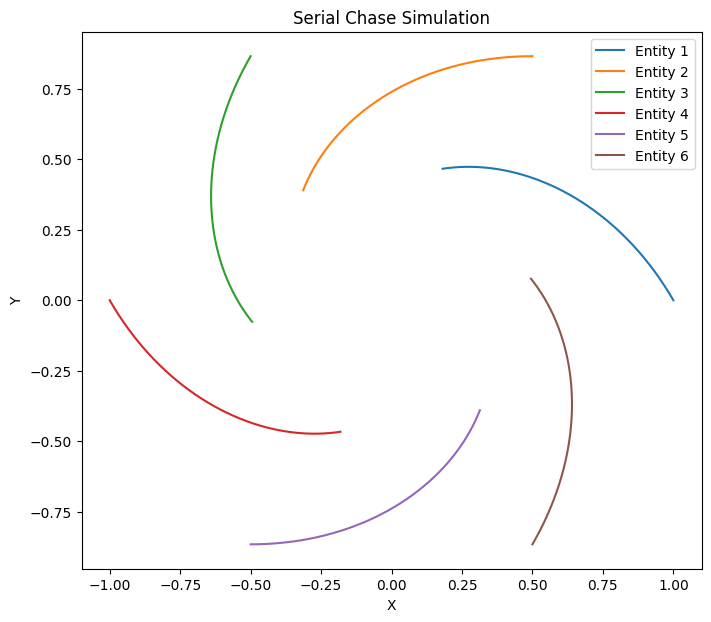

In [24]:
import numpy as np

import matplotlib.pyplot as plt

def serial_chase_simulation(n, delta_t, max_iterations, speed=0.01):
  angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
  positions = np.array([np.cos(angles), np.sin(angles)]).T

  trajectories = [positions.copy()]

  for _ in range(max_iterations):
    new_positions = positions.copy()
    for i in range(n):
      target = (i + 1) % n
      direction = positions[target] - positions[i]
      direction /= np.linalg.norm(direction)
      new_positions[i] += speed * direction * delta_t

    if np.all(np.linalg.norm(new_positions - new_positions[0], axis=1) < 1e-3):
      break

    positions = new_positions
    trajectories.append(positions.copy())

  return np.array(trajectories)

# Parameters
n = 6
delta_t = 0.1
max_iterations = 1000

trajectories = serial_chase_simulation(n, delta_t, max_iterations)

plt.figure(figsize=(8, 8))
for i in range(n):
  plt.plot(trajectories[:, i, 0], trajectories[:, i, 1], label=f'Entity {i+1}')
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Serial Chase Simulation")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()